<a href="https://colab.research.google.com/github/iddadobroc/DSML_Group11_Clustering/blob/main/DSML_Group11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reach for Change

Part 1: Uncovering Donor Profiles Through Clustering
Data Science and Machine Learning Group Project 2025/2026

| Student #    | Name |
| :-------- | :------- |
| 20251702  | Davide Corbo    |
| bbb |   222   |
| ccc    | 333    |
| 20251105 | Kehinde Adewusi |


## First of all, we import pandas and read the dataset.

In [ ]:
import pandas as pd

In [ ]:

df = pd.read_csv('https://raw.githubusercontent.com/iddadobroc/DSML_Group11_Clustering/refs/heads/main/donors_descriptive.csv')
df.head()

,CONTROL_NUMBER,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,...,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING
0,61745,4.0,2.000000,33.0,M,0.0,1.0,H,5.0,20.0,...,0.00,17.50,0.0,0.000,2.0,0.154,0.0,2,T,NaN
1,112703,3.0,-2.341107,NaN,F,1.0,1.0,U,NaN,15.0,...,15.00,15.00,1.0,0.250,1.0,0.100,0.0,3,R,NaN
2,166437,4.0,0.000000,74.0,F,7.0,3.0,H,4.0,10.0,...,0.00,10.67,0.0,0.000,3.0,0.231,1.0,1,U,NaN
3,170621,4.0,4.000000,61.0,M,13.0,1.0,H,6.0,11.0,...,10.00,10.00,2.0,0.286,2.0,0.111,0.0,1,U,NaN
4,44428,6.0,3.000000,75.0,M,3.0,4.0,H,3.0,7.0,...,5.67,5.40,3.0,0.600,5.0,0.500,0.0,2,C,NaN


In [ ]:
df2 = pd.read_csv('https://raw.githubusercontent.com/iddadobroc/DSML_Group11_Clustering/refs/heads/main/donors_descriptive.csv')
df2.head()

,CONTROL_NUMBER,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,...,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING
0,61745,4.0,2.000000,33.0,M,0.0,1.0,H,5.0,20.0,...,0.00,17.50,0.0,0.000,2.0,0.154,0.0,2,T,NaN
1,112703,3.0,-2.341107,NaN,F,1.0,1.0,U,NaN,15.0,...,15.00,15.00,1.0,0.250,1.0,0.100,0.0,3,R,NaN
2,166437,4.0,0.000000,74.0,F,7.0,3.0,H,4.0,10.0,...,0.00,10.67,0.0,0.000,3.0,0.231,1.0,1,U,NaN
3,170621,4.0,4.000000,61.0,M,13.0,1.0,H,6.0,11.0,...,10.00,10.00,2.0,0.286,2.0,0.111,0.0,1,U,NaN
4,44428,6.0,3.000000,75.0,M,3.0,4.0,H,3.0,7.0,...,5.67,5.40,3.0,0.600,5.0,0.500,0.0,2,C,NaN


In [ ]:
# Check number of duplicated IDs
df2["CONTROL_NUMBER"].duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13560 entries, 0 to 13559
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CONTROL_NUMBER               13560 non-null  int64  
 1   CARD_PROM_12                 13297 non-null  float64
 2   CHILDREN                     13289 non-null  float64
 3   DONOR_AGE                    9970 non-null   float64
 4   DONOR_GENDER                 13303 non-null  object 
 5   FILE_CARD_GIFT               13292 non-null  float64
 6   FREQUENCY_STATUS_97NK        13296 non-null  float64
 7   HOME_OWNER                   13292 non-null  object 
 8   INCOME_GROUP                 10273 non-null  float64
 9   LAST_GIFT_AMT                13296 non-null  float64
 10  LIFETIME_CARD_PROM           13289 non-null  float64
 11  LIFETIME_GIFT_AMOUNT         13288 non-null  float64
 12  LIFETIME_GIFT_COUNT          13304 non-null  float64
 13  LIFETIME_MAX_GIF

In [ ]:
df

,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,...,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING
CONTROL_NUMBER,,,,,,,,,,,,,,,,,,,,,
61745,4.0,2.000000,33.0,M,0.0,1.0,H,5.0,20.0,9.0,...,0.00,17.50,0.0,0.000,2.0,0.154,0.0,2,T,NaN
112703,3.0,-2.341107,NaN,F,1.0,1.0,U,NaN,15.0,6.0,...,15.00,15.00,1.0,0.250,1.0,0.100,0.0,3,R,NaN
166437,4.0,0.000000,74.0,F,7.0,3.0,H,4.0,10.0,17.0,...,0.00,10.67,0.0,0.000,3.0,0.231,1.0,1,U,NaN
170621,4.0,4.000000,61.0,M,13.0,1.0,H,6.0,11.0,28.0,...,10.00,10.00,2.0,0.286,2.0,0.111,0.0,1,U,NaN
44428,6.0,3.000000,75.0,M,3.0,4.0,H,3.0,7.0,9.0,...,5.67,5.40,3.0,0.600,5.0,0.500,0.0,2,C,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34797,5.0,0.000000,84.0,M,6.0,1.0,H,6.0,10.0,32.0,...,10.00,10.00,1.0,0.100,2.0,NaN,6.0,2,C,3.0
7550,7.0,1.000000,86.0,F,16.0,3.0,H,2.0,10.0,33.0,...,10.00,7.50,2.0,0.222,4.0,0.211,1.0,2,U,3.0
115215,6.0,2.000000,NaN,M,2.0,3.0,U,1.0,10.0,12.0,...,8.50,9.00,2.0,0.250,NaN,0.235,0.0,2,T,NaN


In [ ]:
df.shape

(13560, 40)

In [ ]:
df.isna().sum()

,0
CONTROL_NUMBER,0
CARD_PROM_12,263
CHILDREN,271
DONOR_AGE,3590
DONOR_GENDER,257
FILE_CARD_GIFT,268
FREQUENCY_STATUS_97NK,264
HOME_OWNER,268
INCOME_GROUP,3287
LAST_GIFT_AMT,264


In [ ]:
df

,CONTROL_NUMBER,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,...,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING
0,61745,4.0,2.000000,33.0,M,0.0,1.0,H,5.0,20.0,...,0.00,17.50,0.0,0.000,2.0,0.154,0.0,2,T,NaN
1,112703,3.0,-2.341107,NaN,F,1.0,1.0,U,NaN,15.0,...,15.00,15.00,1.0,0.250,1.0,0.100,0.0,3,R,NaN
2,166437,4.0,0.000000,74.0,F,7.0,3.0,H,4.0,10.0,...,0.00,10.67,0.0,0.000,3.0,0.231,1.0,1,U,NaN
3,170621,4.0,4.000000,61.0,M,13.0,1.0,H,6.0,11.0,...,10.00,10.00,2.0,0.286,2.0,0.111,0.0,1,U,NaN
4,44428,6.0,3.000000,75.0,M,3.0,4.0,H,3.0,7.0,...,5.67,5.40,3.0,0.600,5.0,0.500,0.0,2,C,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13555,34797,5.0,0.000000,84.0,M,6.0,1.0,H,6.0,10.0,...,10.00,10.00,1.0,0.100,2.0,NaN,6.0,2,C,3.0
13556,7550,7.0,1.000000,86.0,F,16.0,3.0,H,2.0,10.0,...,10.00,7.50,2.0,0.222,4.0,0.211,1.0,2,U,3.0
13557,115215,6.0,2.000000,NaN,M,2.0,3.0,U,1.0,10.0,...,8.50,9.00,2.0,0.250,NaN,0.235,0.0,2,T,NaN
13558,88067,6.0,1.000000,NaN,M,2.0,2.0,U,NaN,15.0,...,10.00,10.00,2.0,0.500,2.0,0.286,0.0,1,S,NaN


#We set CONTROL_NUMBER as index since it represents a unique identifier and does not carry predictive or clustering-relevant information.

In [ ]:
df.set_index("CONTROL_NUMBER", inplace = True)

#Let's try to find some correlations in features

In [ ]:
# Select only numeric columns explicitly
numeric_df = df.select_dtypes(include=["number"])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

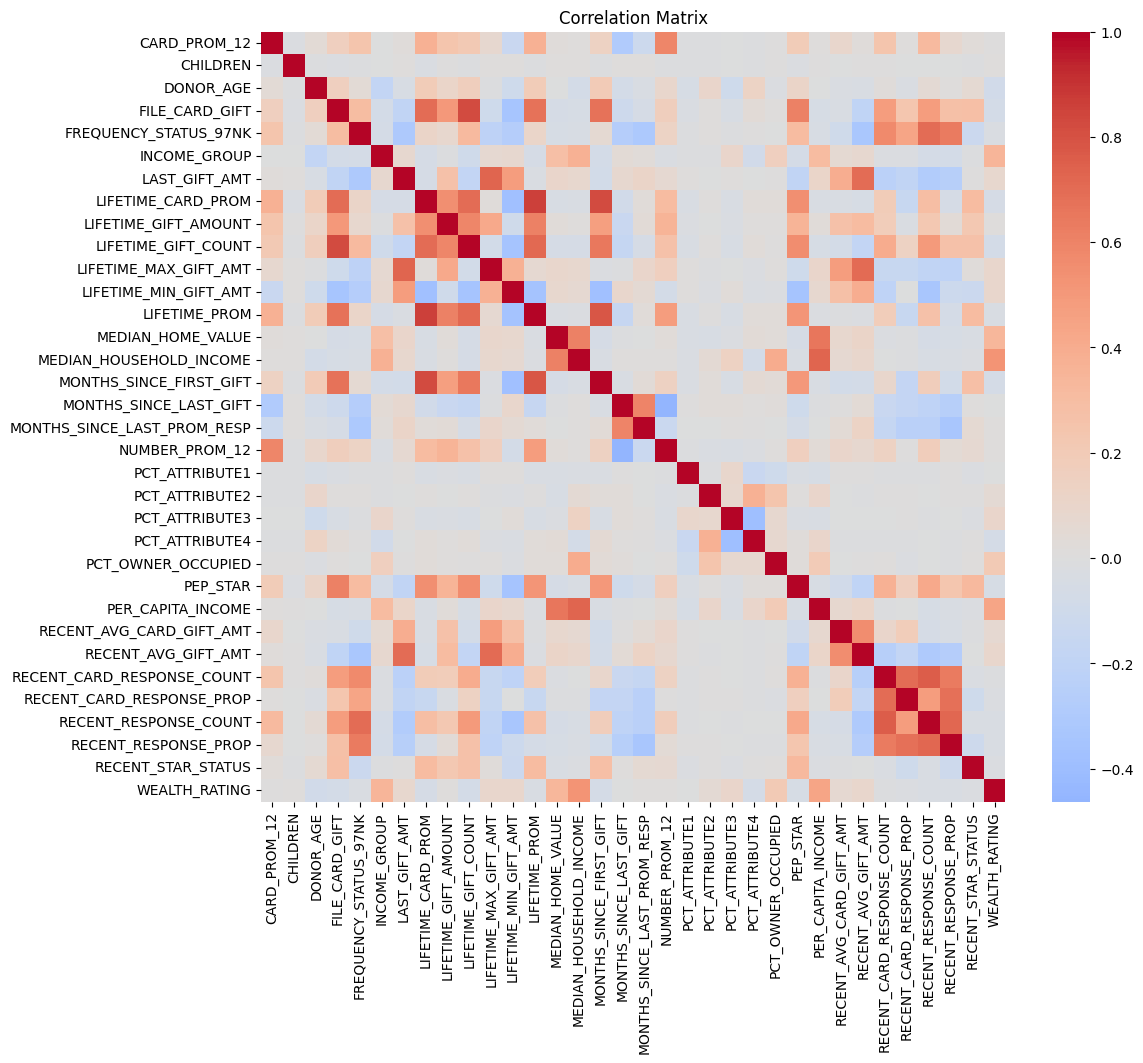

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
# Get high correlations only
threshold = 0.7

high_corr = (
    corr_matrix
    .abs()
    .unstack()
    .sort_values(ascending=False)
)

# Remove self-correlations
high_corr = high_corr[high_corr < 1]

# Keep only strong correlations
high_corr = high_corr[high_corr > threshold]

high_corr.head(20)

,,0
LIFETIME_CARD_PROM,LIFETIME_PROM,0.860207
LIFETIME_PROM,LIFETIME_CARD_PROM,0.860207
FILE_CARD_GIFT,LIFETIME_GIFT_COUNT,0.827515
LIFETIME_GIFT_COUNT,FILE_CARD_GIFT,0.827515
MONTHS_SINCE_FIRST_GIFT,LIFETIME_CARD_PROM,0.823125
LIFETIME_CARD_PROM,MONTHS_SINCE_FIRST_GIFT,0.823125
LIFETIME_PROM,MONTHS_SINCE_FIRST_GIFT,0.783955
MONTHS_SINCE_FIRST_GIFT,LIFETIME_PROM,0.783955
RECENT_RESPONSE_COUNT,RECENT_CARD_RESPONSE_COUNT,0.755177
RECENT_CARD_RESPONSE_COUNT,RECENT_RESPONSE_COUNT,0.755177


# Handling Missing Values

The dataset contains a non-negligible amount of missing values across multiple features. Proper handling of missing data is a critical preprocessing step, as it directly impacts the quality and reliability of the clustering results.

---

## 1. General Strategy

Given the unsupervised nature of clustering, it is essential to avoid introducing artificial bias through inappropriate imputation. Therefore, missing values are handled using a combination of:

* Feature removal (when missingness is excessive)
* Imputation (when information can be reasonably preserved)
* Encoding missingness as information (when relevant)

---

## 2. Feature Removal

Features with a very high proportion of missing values (e.g., above 40–50%) may be excluded from the analysis.

* Example: **WEALTH_RATING**
  This variable contains a substantial number of missing values and may be removed to avoid unreliable imputations.

This decision is justified when:

* The feature is not essential to the chosen perspective
* Alternative variables provide similar information

---

## 3. Numerical Features

For numerical variables, missing values can be handled using:

* **Median Imputation**
  Preferred over mean due to robustness to outliers.
  Suitable for variables such as income, donation amounts, and counts

* **Group-wise Imputation**
  Missing values can be filled based on related features
  (e.g., imputing income using `INCOME_GROUP`)

---

## 4. Categorical Features

For categorical variables, common strategies include:

* **Mode Imputation**
  Replace missing values with the most frequent category

* **Explicit "Unknown" Category**
  Treat missing values as a separate category
  This is particularly useful when missingness may carry information

---

## 5. Missingness as Information

In some cases, the absence of data may itself be informative. For example:

* Missing donation-related values may indicate low engagement
* Missing demographic variables may reflect incomplete profiling

When appropriate, additional binary indicators can be created:

* **IS_MISSING_FEATURE_X** → 1 if missing, 0 otherwise

---

## 6. Consistency Across Perspectives

Different perspectives may require different handling strategies:

* **Behavioral perspective**
  Prioritize preserving donation-related information.
  Avoid dropping key behavioral variables

* **Socio-economic perspective**
  Greater tolerance for dropping features with excessive missingness.
  Focus on stable demographic indicators

---

## 7. Summary

The chosen approach to handling missing values aims to:

* Minimize information loss
* Avoid introducing bias
* Preserve meaningful patterns in the data

A careful balance between removal, imputation, and encoding ensures that the dataset remains suitable for effective clustering analysis.


# Clustering Perspectives

To gain a comprehensive understanding of the donor base, we adopt two distinct clustering perspectives: a **behavioral perspective** and a **socio-economic perspective**. This approach allows us to analyze donors both in terms of their interaction patterns with the organization and their underlying demographic characteristics.

---

## 1. Behavioral Perspective

The behavioral perspective focuses on how donors interact with the organization, particularly in terms of their donation patterns and engagement levels. This approach is inspired by the well-known RFM (Recency, Frequency, Monetary) framework commonly used in marketing analytics.

### Selected Features

* **RECENT_AVG_GIFT_AMT** → Average recent donation amount
* **RECENT_RESPONSE_PROP** → Engagement level with recent campaigns
* **RECENT_RESPONSE_COUNT** → Number of recent responses
* **MONTHS_SINCE_LAST_GIFT** → Recency of last donation
* **MONTHS_SINCE_FIRST_GIFT** → Donor lifetime
* **LIFETIME_GIFT_AMOUNT** → Total contribution over time
* **LIFETIME_GIFT_COUNT** → Number of donations
* **LAST_GIFT_AMT** → Most recent donation value

### Objective

The goal of this perspective is to identify segments such as:

* High-value and loyal donors
* Occasionally engaged donors
* Inactive or lapsed donors

This segmentation is particularly useful for designing targeted fundraising strategies and improving donor retention.

---

## 2. Socio-Economic Perspective

The socio-economic perspective focuses on the characteristics of donors, such as their demographic profile, economic status, and living environment. Unlike the behavioral approach, this perspective aims to understand *who the donors are*, rather than *how they behave*.

### Selected Features

* **DONOR_AGE** → Age of the donor
* **INCOME_GROUP** → Income classification
* **MEDIAN_HOUSEHOLD_INCOME** → Area-level income
* **MEDIAN_HOME_VALUE** → Property value proxy
* **PER_CAPITA_INCOME** → Economic context
* **PCT_OWNER_OCCUPIED** → Housing stability indicator
* **HOME_OWNER** → Ownership status
* **SES** → Socio-economic segment
* **URBANICITY** → Geographic context (urban/rural)
* **CHILDREN** → Household composition

### Objective

The goal of this perspective is to identify segments such as:

* High-income urban donors
* Lower-income rural donors
* Family-oriented donor groups

This segmentation helps tailor communication strategies and better align campaigns with donor profiles.

---

## Summary

By combining these two perspectives, we obtain a more holistic view of the donor base:

* The **behavioral perspective** explains *how donors act*
* The **socio-economic perspective** explains *who donors are*

This dual approach enables more effective and personalized outreach strategies.


# Feature Engineering

To enhance the quality of our clustering results, we perform feature engineering tailored to each perspective. Creating new variables allows us to better capture underlying patterns that are not directly observable from the original features.

---

## 1. Feature Engineering for Behavioral Perspective

The goal of feature engineering in this context is to better represent donor engagement, donation intensity, and recency dynamics.

### Proposed Features

* **AVG_GIFT**
  Average donation per transaction:
  `LIFETIME_GIFT_AMOUNT / LIFETIME_GIFT_COUNT`
  → Captures typical donation size, reducing redundancy between total amount and count.

* **ENGAGEMENT_RATE**
  Response efficiency to campaigns:
  `RECENT_RESPONSE_COUNT / NUMBER_PROM_12`
  → Measures how responsive a donor is relative to the number of solicitations received.

* **CARD_ENGAGEMENT_RATE**
  `RECENT_CARD_RESPONSE_COUNT / CARD_PROM_12`
  → Focuses specifically on card-based campaign effectiveness.

* **RECENCY_SCORE**
  Transformed recency metric:
  `1 / (1 + MONTHS_SINCE_LAST_GIFT)`
  → Converts recency into a score where more recent donors receive higher values.

* **DONATION_FREQUENCY**
  `LIFETIME_GIFT_COUNT / MONTHS_SINCE_FIRST_GIFT`
  → Normalizes donation count over time, capturing how frequently a donor contributes.

### Rationale

These engineered features:

* Reduce redundancy among highly correlated variables
* Provide normalized and more interpretable measures
* Improve the ability of clustering algorithms to detect meaningful behavioral patterns

---

## 2. Feature Engineering for Socio-Economic Perspective

In this perspective, feature engineering focuses on combining existing variables to better represent economic status and living conditions.

### Proposed Features

* **INCOME_PER_CAPITA_RATIO**
  `MEDIAN_HOUSEHOLD_INCOME / PER_CAPITA_INCOME`
  → Provides insight into household composition and income distribution.

* **WEALTH_PROXY**
  Combination of economic indicators such as:
  `MEDIAN_HOME_VALUE + MEDIAN_HOUSEHOLD_INCOME`
  → Acts as a proxy for overall wealth level.

* **HOUSING_STABILITY**
  Derived from:
  `HOME_OWNER` and `PCT_OWNER_OCCUPIED`
  → Indicates stability of living conditions and neighborhood ownership patterns.

* **FAMILY_SIZE_PROXY**
  Based on:
  `CHILDREN`
  → Captures household structure, which may influence donation behavior.

### Rationale

These features:

* Aggregate multiple socio-economic signals into more informative variables
* Capture latent concepts such as wealth and stability
* Improve separability between different demographic profiles

---

## Summary

Feature engineering plays a key role in improving clustering performance by:

* Enhancing interpretability of variables
* Reducing noise and redundancy
* Highlighting meaningful behavioral and socio-economic patterns

These engineered features are expected to lead to more coherent and actionable donor segments.


#Frow now on we work with copies of the original df

In [ ]:
df1=df.copy()

In [ ]:
df1.drop(columns=["WEALTH_RATING"], inplace = True)

In [ ]:
df1

,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,...,RECENCY_STATUS_96NK,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY
CONTROL_NUMBER,,,,,,,,,,,,,,,,,,,,,
61745,4.0,2.000000,33.0,M,0.0,1.0,H,5.0,20.0,9.0,...,A,0.00,17.50,0.0,0.000,2.0,0.154,0.0,2,T
112703,3.0,-2.341107,NaN,F,1.0,1.0,U,NaN,15.0,6.0,...,N,15.00,15.00,1.0,0.250,1.0,0.100,0.0,3,R
166437,4.0,0.000000,74.0,F,7.0,3.0,H,4.0,10.0,17.0,...,NaN,0.00,10.67,0.0,0.000,3.0,0.231,1.0,1,U
170621,4.0,4.000000,61.0,M,13.0,1.0,H,6.0,11.0,28.0,...,A,10.00,10.00,2.0,0.286,2.0,0.111,0.0,1,U
44428,6.0,3.000000,75.0,M,3.0,4.0,H,3.0,7.0,9.0,...,N,5.67,5.40,3.0,0.600,5.0,0.500,0.0,2,C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34797,5.0,0.000000,84.0,M,6.0,1.0,H,6.0,10.0,32.0,...,A,10.00,10.00,1.0,0.100,2.0,NaN,6.0,2,C
7550,7.0,1.000000,86.0,F,16.0,3.0,H,2.0,10.0,33.0,...,S,10.00,7.50,2.0,0.222,4.0,0.211,1.0,2,U
115215,6.0,2.000000,NaN,M,2.0,3.0,U,1.0,10.0,12.0,...,A,8.50,9.00,2.0,0.250,NaN,0.235,0.0,2,T


In [ ]:
df1.describe(include="all")

,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,...,RECENCY_STATUS_96NK,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY
count,13297.000000,13289.000000,9970.000000,13303,13292.000000,13296.000000,13292,10273.000000,13296.000000,13289.000000,...,13294,13309.000000,13292.000000,13282.000000,13286.000000,13294.000000,13308.000000,13285.000000,13274,13282
unique,NaN,NaN,NaN,3,NaN,NaN,2,NaN,NaN,NaN,...,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,6
top,NaN,NaN,NaN,F,NaN,NaN,H,NaN,NaN,NaN,...,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,S
freq,NaN,NaN,NaN,7222,NaN,NaN,7251,NaN,NaN,NaN,...,8202,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6365,3103
mean,5.381058,2.004998,58.870864,NaN,5.253405,1.990869,NaN,3.922943,16.622972,18.641620,...,NaN,11.730338,15.394193,1.739533,0.231931,3.047406,0.190553,0.900961,NaN,NaN
std,1.313753,1.473369,17.572796,NaN,4.812068,1.145976,NaN,1.950277,12.930434,8.895656,...,NaN,11.174975,10.725632,1.620748,0.195624,2.123053,0.119483,2.637899,NaN,NaN
min,1.000000,-2.341107,0.000000,NaN,-10.100341,-1.365242,NaN,-1.728999,-21.718664,-7.188999,...,NaN,-22.188242,-16.958872,-3.703178,-0.369805,-3.222148,-0.181767,-7.806416,NaN,NaN
25%,5.000000,1.000000,46.000000,NaN,2.000000,1.000000,NaN,2.000000,10.000000,11.000000,...,NaN,5.000000,10.000000,1.000000,0.100000,2.000000,0.105000,0.000000,NaN,NaN
50%,6.000000,2.000000,60.000000,NaN,4.000000,2.000000,NaN,4.000000,15.000000,18.000000,...,NaN,10.500000,14.250000,1.000000,0.200000,3.000000,0.167000,0.000000,NaN,NaN
75%,6.000000,3.000000,73.000000,NaN,8.000000,3.000000,NaN,5.000000,20.000000,26.000000,...,NaN,16.000000,20.000000,2.000000,0.333000,4.000000,0.250000,1.000000,NaN,NaN


#It looks like many features have some records with negative values. We need to fix this.




In [ ]:
# Select only numeric columns
numeric_df = df1.select_dtypes(include=["number"])

# Count negative values
neg_counts = (numeric_df < 0).sum()

neg_counts[neg_counts > 0]

,0
CHILDREN,75
FILE_CARD_GIFT,64
FREQUENCY_STATUS_97NK,70
INCOME_GROUP,61
LAST_GIFT_AMT,70
LIFETIME_CARD_PROM,68
LIFETIME_GIFT_AMOUNT,66
LIFETIME_GIFT_COUNT,70
LIFETIME_MAX_GIFT_AMT,67
LIFETIME_MIN_GIFT_AMT,64


# #What do we do with negative values? Do we use mean or median values to replace them? Do we delete those records?

#Since K-Means does not support missing values, all missing data need to be handled through imputation prior to modeling.

# We also need to check for the many outliers that this dataset contains

##We need to understand what the value of "SES" mean. Then we relate it to similar features to understand.

In [ ]:
df1["SES"].unique()

array(['2', '3', '1', '4', nan, '?'], dtype=object)

In [ ]:
df1[["SES","INCOME_GROUP","MEDIAN_HOME_VALUE","MEDIAN_HOUSEHOLD_INCOME","PER_CAPITA_INCOME"]]

,SES,INCOME_GROUP,MEDIAN_HOME_VALUE,MEDIAN_HOUSEHOLD_INCOME,PER_CAPITA_INCOME
CONTROL_NUMBER,,,,,
61745,2,5.0,566.0,315.0,12827.0
112703,3,NaN,318.0,148.0,7787.0
166437,1,4.0,1669.0,373.0,13965.0
170621,1,6.0,1464.0,488.0,24123.0
44428,2,3.0,936.0,249.0,15008.0
...,...,...,...,...,...
34797,2,6.0,558.0,285.0,14603.0
7550,2,2.0,1116.0,NaN,21881.0
115215,2,1.0,421.0,169.0,6459.0


In [ ]:
# Compute mean values by SES
df1.groupby("SES")[[
    "INCOME_GROUP",
    "MEDIAN_HOME_VALUE",
    "MEDIAN_HOUSEHOLD_INCOME",
    "PER_CAPITA_INCOME"
]].mean()

,INCOME_GROUP,MEDIAN_HOME_VALUE,MEDIAN_HOUSEHOLD_INCOME,PER_CAPITA_INCOME
SES,,,,
1,4.967228,1800.416183,478.707512,23121.434856
2,3.633208,809.960749,303.062529,13520.044241
3,2.959423,582.590675,225.587531,10390.934975
4,2.806228,704.540323,191.192245,9672.928687
?,3.840676,1065.728343,335.352146,15409.174374


#It looks like from 1 to 4 we have wealthiest groups in descending order



In [ ]:
df1["INCOME_GROUP"].unique()

array([ 5.        ,         nan,  4.        ,  6.        ,  3.        ,
        2.        ,  9.49079901,  1.        ,  7.        , -1.72899876])

#Here we need to delete values " 9.49079901" "-1.72899876"

##The higher the income_group, the richer the person

In [ ]:
df1.describe()

,CARD_PROM_12,CHILDREN,DONOR_AGE,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,LIFETIME_GIFT_AMOUNT,LIFETIME_GIFT_COUNT,...,PCT_OWNER_OCCUPIED,PEP_STAR,PER_CAPITA_INCOME,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS
count,13297.000000,13289.000000,9970.000000,13292.000000,13296.000000,10273.000000,13296.000000,13289.000000,13288.000000,13304.000000,...,13297.000000,13295.000000,13305.000000,13309.000000,13292.000000,13282.000000,13286.000000,13294.000000,13308.000000,13285.000000
mean,5.381058,2.004998,58.870864,5.253405,1.990869,3.922943,16.622972,18.641620,105.010105,9.967199,...,69.660920,0.504260,15910.503294,11.730338,15.394193,1.739533,0.231931,3.047406,0.190553,0.900961
std,1.313753,1.473369,17.572796,4.812068,1.145976,1.950277,12.930434,8.895656,112.318930,9.152911,...,22.525711,0.513613,9215.065476,11.174975,10.725632,1.620748,0.195624,2.123053,0.119483,2.637899
min,1.000000,-2.341107,0.000000,-10.100341,-1.365242,-1.728999,-21.718664,-7.188999,-245.473199,-18.583020,...,0.000000,-0.529861,-12761.372943,-22.188242,-16.958872,-3.703178,-0.369805,-3.222148,-0.181767,-7.806416
25%,5.000000,1.000000,46.000000,2.000000,1.000000,2.000000,10.000000,11.000000,41.000000,4.000000,...,59.000000,0.000000,10878.000000,5.000000,10.000000,1.000000,0.100000,2.000000,0.105000,0.000000
50%,6.000000,2.000000,60.000000,4.000000,2.000000,4.000000,15.000000,18.000000,80.000000,8.000000,...,76.000000,1.000000,13893.000000,10.500000,14.250000,1.000000,0.200000,3.000000,0.167000,0.000000
75%,6.000000,3.000000,73.000000,8.000000,3.000000,5.000000,20.000000,26.000000,133.000000,14.000000,...,85.000000,1.000000,18443.000000,16.000000,20.000000,2.000000,0.333000,4.000000,0.250000,1.000000
max,17.000000,6.264709,108.934261,32.000000,5.283869,9.490799,450.000000,55.000000,3775.000000,95.000000,...,134.826095,2.003609,174523.000000,260.000000,260.000000,9.000000,1.000000,16.000000,1.000000,22.000000
